In [3]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [4]:
#Function 2
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 2.csv') 
columns = ['Input 1', 'Input 2', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.713573, 0.445985, 0.6157097213349471])
data.loc[len(data)] = new_data7
#Add Week 8's data to our pandas dataframe
new_data8 = np.array([0.734435, 0.506061, 0.393451984])
data.loc[len(data)] = new_data8

#Add Week 9's data to our pandas dataframe
new_data9 = np.array([0.666793, 0.462029, 0.4671094381976445])
data.loc[len(data)] = new_data9
#Add Week 10's data to our pandas dataframe
new_data10 = np.array([0.691329, 0.884581, 0.6011979340999474])
data.loc[len(data)] = new_data10
data

,Input 1,Input 2,Outputs
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


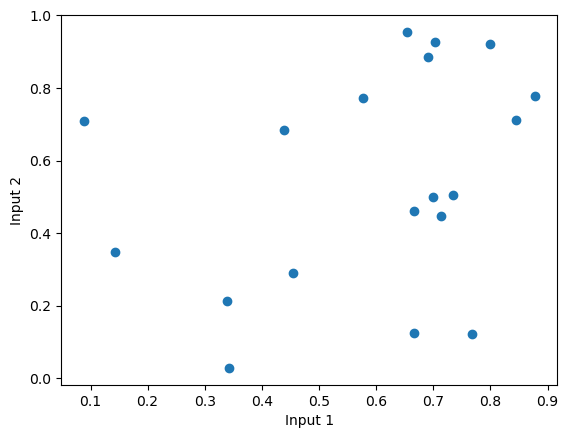

In [5]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2']])
Y = np.array(data[['Outputs']])
#Visualise explored points
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

In [6]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Outputs
Input 1,1.000000,0.314111,0.685832
Input 2,0.314111,1.000000,0.276696
Outputs,0.685832,0.276696,1.000000


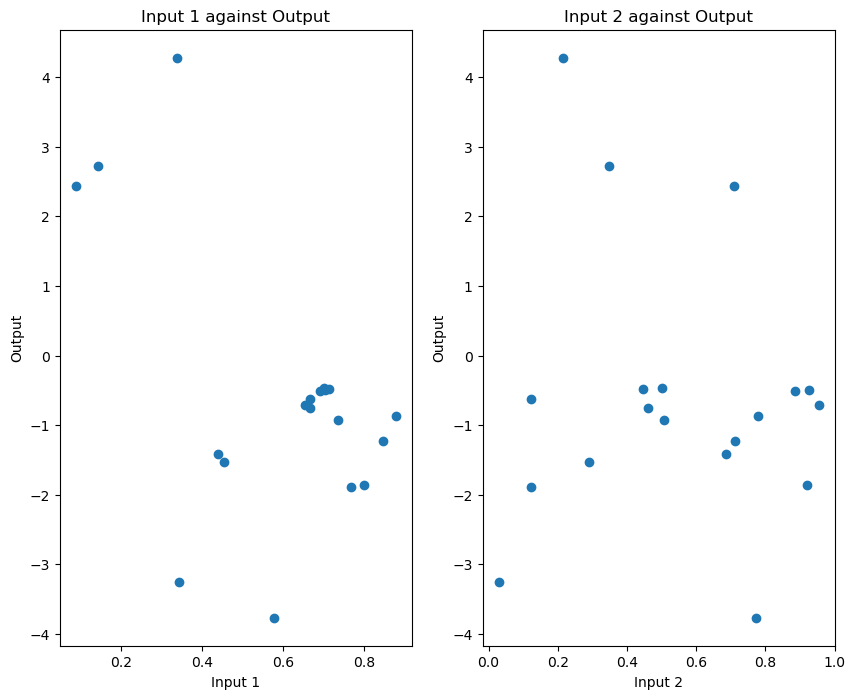

In [7]:
#Plotting each Input against the signed log of the output
#Plotting the log of the (absolute value) output since the values are very small
fig, ax = plt.subplots(1,2, figsize = (10,8))
ax[0].scatter(X[:,0], np.sign(Y)*np.log(np.abs(Y)+1e-300))
ax[1].scatter(X[:,1], np.sign(Y)*np.log(np.abs(Y)+1e-300))

#Creating titles and axis labels
ax[0].set_title('Input 1 against Output')
ax[1].set_title('Input 2 against Output')

ax[0].set_xlabel('Input 1')
ax[0].set_ylabel('Output')

ax[1].set_xlabel('Input 2')
ax[1].set_ylabel('Output')
plt.show()

In [8]:
#We now use random forest regression to generate a list of promising points for a GP
#to evaluate
from sklearn.ensemble import RandomForestRegressor
#Using randomized search CV for light hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [0.5, 0.7, 1.0]
}

rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1, random_state = 42)

search.fit(X, Y.ravel())

rf_best = search.best_estimator_
print("Tuned RF Model:", rf_best)

Tuned RF Model: RandomForestRegressor(min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                      random_state=42)


In [9]:
#Use latin hypercube sampling to create a grid 
d = 2
n = 10000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Use random forest model to outputs from the grid
Y_pred = rf_best.predict(grid)

#Select the top 200 points
n_select = 200
top_idx = np.argsort(Y_pred)[-n_select:]
X_candidates = grid[top_idx]

In [10]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale_bounds= (1e-2,1e1), nu = nu)
print("Kernel;", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)

gp.fit(X,Y)



#fit GP to candidate points generated by Random Forest model
mu, std = gp.predict(X_candidates, return_std = True)

#fit GP to candidate points generated over entire domain
mu_grid, std_grid = gp.predict(grid, return_std = True)

Kernel; Matern(length_scale=1, nu=2.5)


In [12]:
#Calculate UCB 
beta = 1.96 #set exploration parameter
#UCB for points selected by Random forest model
UCB = mu + beta*std 
#UCB for entire domain
UCB_grid = mu_grid + beta*std_grid 
#Find point selected by random forest model that maximises UCB 
X_next = X_candidates[np.argmax(UCB)]
#Find point over entire domain that maximises UCB
X_next_grid = grid[np.argmax(UCB_grid)]
print("Random Forest Hybrid model next suggested point:", np.round(X_next,6))
print("Pure GP model next suggested point:", np.round(X_next_grid,6))

Random Forest Hybrid model next suggested point: [0.708254 0.378104]
Pure GP model next suggested point: [0.663896 0.537578]
